# EDA — Defining the major fossil-fuel economies

RQ1 and RQ2 focus on the countries for which the energy transition matters most economically. This notebook defines
that group from the external data: the countries in the **top quartile of both** fossil-fuel production (OWID, TWh)
and fossil-fuel rents (World Bank, % of GDP). We call them the **major fossil-fuel economies**.

- **Input:** `datasets/prepared_data/master_panel_country_year.csv` (from `03_external_data`)
- **Output:** `datasets/prepared_data/major_fossil_economies.csv` (one row per country, with the flag
  `major_fossil_economy`) and three figures in `figures/`

**Run order:** 01 → 02 → 03 → this notebook → 05 → 06.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIG_DIR = '../figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Same colours and style as 05_eda_combined, so all report figures match
MAJOR_COLOR = '#2a78d6'
OTHER_COLOR = '#eb6834'
INK = '#52514e'

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': '#c3c2b7',
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.6,
    'axes.axisbelow': True,
    'axes.titlesize': 11,
    'axes.labelcolor': INK,
    'xtick.color': INK,
    'ytick.color': INK,
    'legend.frameon': False,
})

## Step 1 — Average production and rents over 2015–2021

We summarise each country by its **mean** over 2015–2021. 2015 is the year of the Paris Agreement, and the World Bank
rents stop in 2021, so this is the longest period both measures cover. Averaging over seven years also smooths out
single-year swings, such as the 2020 COVID drop or oil-price spikes.

Rents are available for about 200 countries, production only for 73, because OWID's source (the Energy Institute's
*Statistical Review of World Energy*) only reports on major producers.

In [2]:
panel = pd.read_csv('../datasets/prepared_data/master_panel_country_year.csv')
window = panel[panel['Year'].between(2015, 2021)]

rents = window.groupby(['iso3', 'country'])['total_fossil_rents_pct_gdp'].mean().dropna()
production = window.groupby(['iso3', 'country'])['total_production_twh'].mean().dropna()

print(f"Mean rents available for {len(rents)} countries, mean production for {len(production)} countries")
pd.DataFrame({'rents_pct_gdp': rents.describe(), 'production_twh': production.describe()}).round(2)

Mean rents available for 202 countries, mean production for 73 countries


,rents_pct_gdp,production_twh
count,202.00,73.00
mean,3.02,1791.96
std,7.33,4171.10
min,0.00,6.79
25%,0.00,103.08
50%,0.06,366.51
75%,1.40,1642.66
max,49.21,25272.11


## Step 2 — Economic dependence: top quartile of fossil-fuel rents

Fossil-fuel rents are the value of oil, gas and coal production at world prices minus the cost of producing it, as a
share of GDP. They measure how much a country's economy **depends** on fossil fuels. They do not measure exports:
a country can have high rents and still use most of its production at home. The rent distribution is very skewed
(the median is below 0.1% of GDP), so we use the top quartile as the cut-off.

In [3]:
rent_cutoff = rents.quantile(0.75)
rent_dependent = rents[rents >= rent_cutoff].sort_values(ascending=False)

print(f"Top-quartile cut-off: {rent_cutoff:.2f}% of GDP")
print(f"{len(rent_dependent)} fossil-fuel-dependent countries")
rent_dependent.round(2)

Top-quartile cut-off: 1.40% of GDP
51 fossil-fuel-dependent countries


iso3  country             
TLS   Timor-Leste             49.21
IRQ   Iraq                    38.22
KWT   Kuwait                  36.78
LBY   Libya                   26.99
COG   Congo, Rep.             26.27
SAU   Saudi Arabia            23.88
AGO   Angola                  23.77
OMN   Oman                    22.94
IRN   Iran, Islamic Rep.      21.99
QAT   Qatar                   21.12
AZE   Azerbaijan              20.19
GNQ   Equatorial Guinea       19.56
BRN   Brunei Darussalam       18.96
DZA   Algeria                 16.81
ARE   United Arab Emirates    14.98
TKM   Turkmenistan            14.35
GAB   Gabon                   13.65
BHR   Bahrain                 12.70
KAZ   Kazakhstan              12.27
CPV   Cabo Verde              12.09
TCD   Chad                    11.62
SSD   South Sudan             10.39
RUS   Russian Federation      10.18
PNG   Papua New Guinea         8.24
TTO   Trinidad and Tobago      7.58
MNG   Mongolia                 6.98
NOR   Norway                   5.99
U

## Step 3 — Size: top quartile of fossil-fuel production

Rents alone would also select small economies that depend on fossil fuels but produce very little, such as
Timor-Leste. To focus on countries that matter for global supply, we also take the top quartile of mean annual
production (coal + oil + gas, in TWh).

In [4]:
production_cutoff = production.quantile(0.75)
large_producers = production[production >= production_cutoff].sort_values(ascending=False)

print(f"Top-quartile cut-off: {production_cutoff:.2f} TWh per year")
print(f"{len(large_producers)} large fossil-fuel producers")
large_producers.round(1)

Top-quartile cut-off: 1642.66 TWh per year
19 large fossil-fuel producers


iso3  country             
CHN   China                   25272.1
USA   United States           19883.4
RUS   Russian Federation      15255.0
SAU   Saudi Arabia             7542.0
AUS   Australia                4976.9
CAN   Canada                   4914.6
IRN   Iran, Islamic Rep.       4407.9
IDN   Indonesia                4347.1
IND   India                    4168.6
QAT   Qatar                    2613.3
IRQ   Iraq                     2584.5
ARE   United Arab Emirates     2567.3
NOR   Norway                   2175.9
BRA   Brazil                   1972.6
KAZ   Kazakhstan               1825.6
KWT   Kuwait                   1804.4
MEX   Mexico                   1714.8
ZAF   South Africa             1648.0
DZA   Algeria                  1642.7
Name: total_production_twh, dtype: float64

## Step 4 — Intersection: the major fossil-fuel economies

A country is a **major fossil-fuel economy** if it is in both top quartiles: a large producer whose economy also
depends on fossil fuels. These are the countries with the strongest economic incentive to say one thing about the
energy transition at the UN and do another at home, which is what our questions are about.

The intersection is matched on ISO-3 code. It deliberately leaves out large producers with diversified economies. The
cell below lists them with their rents, because this choice has to be explained in the report.

In [5]:
rent_iso3 = set(rent_dependent.index.get_level_values('iso3'))
producer_iso3 = set(large_producers.index.get_level_values('iso3'))
major_iso3 = rent_iso3 & producer_iso3

print(f"{len(major_iso3)} major fossil-fuel economies: {', '.join(sorted(major_iso3))}")

excluded = large_producers[~large_producers.index.get_level_values('iso3').isin(major_iso3)]
print("\nLarge producers left out because their rents are below the cut-off:")
pd.DataFrame({
    'mean_production_twh': excluded.round(0),
    'mean_rents_pct_gdp': rents.reindex(excluded.index).round(2),
})

15 major fossil-fuel economies: ARE, AUS, BRA, DZA, IDN, IRN, IRQ, KAZ, KWT, MEX, NOR, QAT, RUS, SAU, ZAF

Large producers left out because their rents are below the cut-off:


,,mean_production_twh,mean_rents_pct_gdp
iso3,country,,
CHN,China,25272.0,0.91
USA,United States,19883.0,0.45
CAN,Canada,4915.0,1.35
IND,India,4169.0,1.30


The four large producers left out are the **United States** (0.45% of GDP) and **China** (0.91%), clearly below
the cut-off, and **Canada** (1.35%) and **India** (1.30%), just below it. Their economies are too large and
diversified for fossil fuels to dominate them.

**Venezuela** is also missing: the World Bank has no rent data for it over 2015–2021, so it cannot enter the rent
ranking at all.

## Step 5 — Figures

The scatter plot shows the whole selection in one picture. Each dot is one of the 72 countries with both production
and rent data; the dashed lines are the two top-quartile cut-offs, and the shaded top-right region contains the major
fossil-fuel economies. Both axes are logarithmic, because production ranges from about 7 to 25,000 TWh and rents from
0.003% to 38% of GDP. Only the four large producers that fall outside the group are labelled; the 15 blue countries
are listed in Step 4 (and in Table 1 of the report). This is the figure intended for the report, so it is sized for
the report's text width.

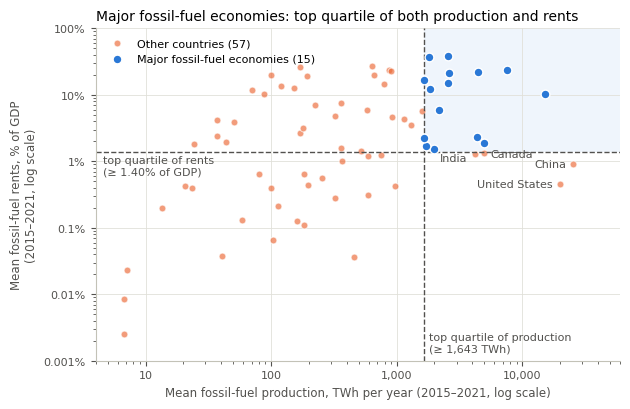

In [6]:
sel = pd.concat([production.rename('production'), rents.rename('rents')], axis=1, join='inner').reset_index()
sel['major'] = sel['iso3'].isin(major_iso3)
majors, others = sel[sel['major']], sel[~sel['major']]

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(4, 60000)
ax.set_ylim(0.001, 100)

# Selection region (top-right quadrant) and the two cut-offs
ax.fill_between([production_cutoff, 60000], rent_cutoff, 100, color=MAJOR_COLOR, alpha=0.07, linewidth=0, zorder=0)
ax.axvline(production_cutoff, color=INK, linestyle='--', linewidth=1)
ax.axhline(rent_cutoff, color=INK, linestyle='--', linewidth=1)
ax.text(production_cutoff * 1.1, 0.0013, f'top quartile of production\n(≥ {production_cutoff:,.0f} TWh)',
        fontsize=8, color=INK, va='bottom')
ax.text(4.6, rent_cutoff / 1.12, f'top quartile of rents\n(≥ {rent_cutoff:.2f}% of GDP)',
        fontsize=8, color=INK, va='top')

ax.scatter(others['production'], others['rents'], s=24, color=OTHER_COLOR, alpha=0.65,
           edgecolor='white', linewidth=0.8, label=f'Other countries ({len(others)})')
ax.scatter(majors['production'], majors['rents'], s=40, color=MAJOR_COLOR,
           edgecolor='white', linewidth=1, label=f'Major fossil-fuel economies ({len(majors)})', zorder=3)

# Label only the large producers that fall outside the group: they are what the selection rule has to explain.
labels = {'CHN': (-5, 0, 'right'), 'USA': (-5, 0, 'right'), 'CAN': (5, -1, 'left'), 'IND': (-5, -3, 'right')}
for _, row in sel[sel['iso3'].isin(labels)].iterrows():
    dx, dy, ha = labels[row['iso3']]
    ax.annotate(row['country'], (row['production'], row['rents']), xytext=(dx, dy),
                textcoords='offset points', fontsize=8, color=INK, ha=ha, va='center')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:g}%'))
ax.tick_params(labelsize=8)
ax.set_xlabel('Mean fossil-fuel production, TWh per year (2015–2021, log scale)', fontsize=8.5)
ax.set_ylabel('Mean fossil-fuel rents, % of GDP\n(2015–2021, log scale)', fontsize=8.5)
ax.set_title('Major fossil-fuel economies: top quartile of both production and rents', loc='left', fontsize=10)
ax.legend(loc='upper left', fontsize=8, scatterpoints=1)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/eda_major_fossil_economies.png', dpi=200, bbox_inches='tight')
plt.show()

For reference, the two top-quartile lists as bar charts. Bars in blue are also in the other list, i.e. they are
major fossil-fuel economies.

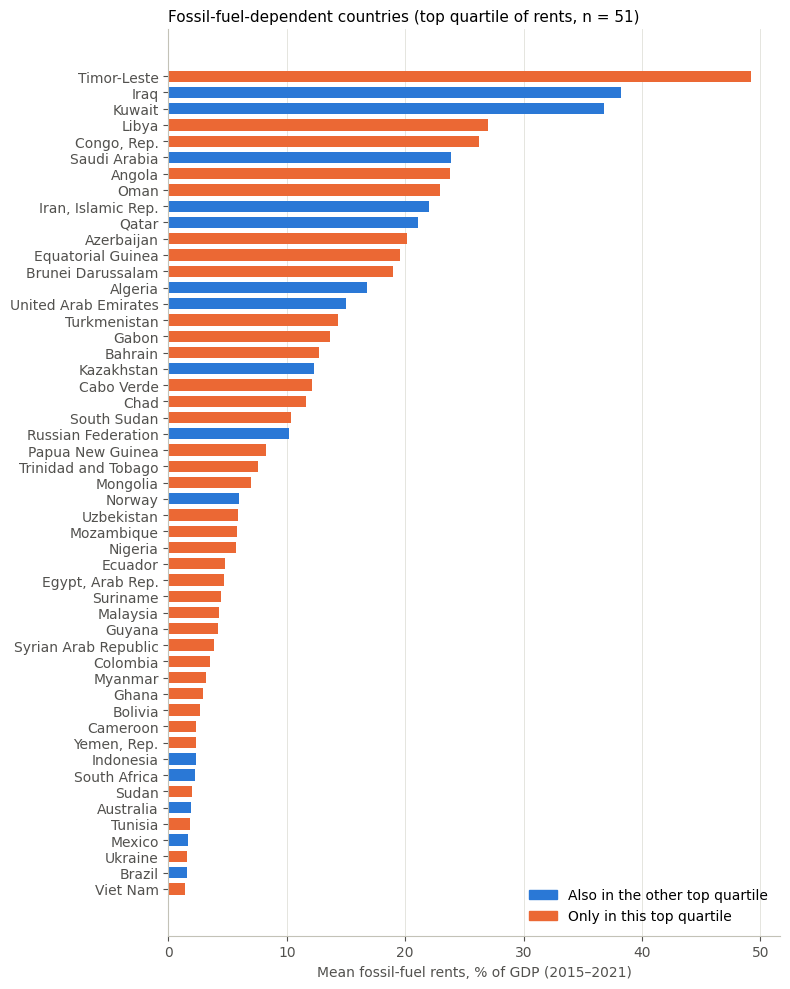

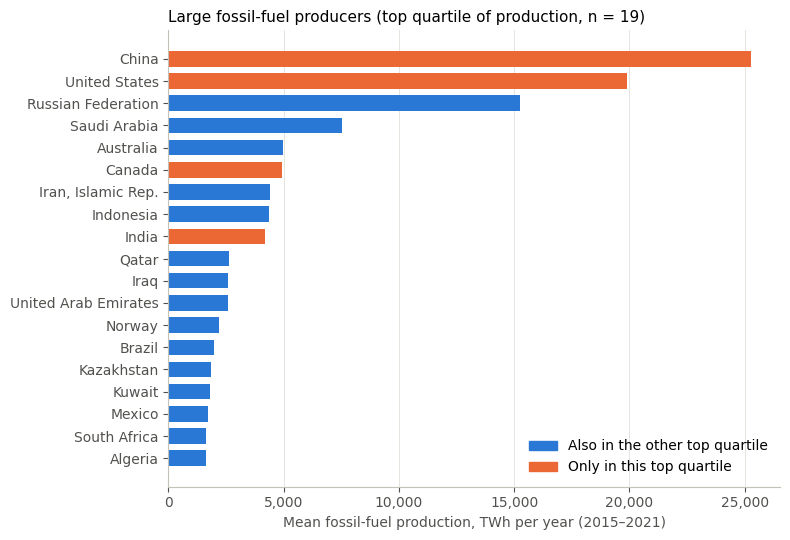

In [7]:
def ranked_bars(series, xlabel, title, filename, height):
    s = series.sort_values()
    colors = [MAJOR_COLOR if iso3 in major_iso3 else OTHER_COLOR for iso3 in s.index.get_level_values('iso3')]
    fig, ax = plt.subplots(figsize=(8, height))
    ax.barh(s.index.get_level_values('country'), s.values, color=colors, height=0.7)
    ax.grid(axis='y', visible=False)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.set_xlabel(xlabel)
    ax.set_title(title, loc='left')
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=MAJOR_COLOR), plt.Rectangle((0, 0), 1, 1, color=OTHER_COLOR)],
              labels=['Also in the other top quartile', 'Only in this top quartile'], loc='lower right')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/{filename}', dpi=200, bbox_inches='tight')
    plt.show()


ranked_bars(rent_dependent, 'Mean fossil-fuel rents, % of GDP (2015–2021)',
            f'Fossil-fuel-dependent countries (top quartile of rents, n = {len(rent_dependent)})',
            'eda_top_quartile_rents.png', height=10)
ranked_bars(large_producers, 'Mean fossil-fuel production, TWh per year (2015–2021)',
            f'Large fossil-fuel producers (top quartile of production, n = {len(large_producers)})',
            'eda_top_quartile_production.png', height=5.5)

## Step 6 — Save

We save one row per country in the panel, with `major_fossil_economy` set to `True` for the 15 countries.
`05_eda_combined` (RQ1) and `06_predictive_modelling` (RQ2) both read this file.

In [8]:
major_fossil_economies = panel[['iso3', 'country']].drop_duplicates().reset_index(drop=True)
major_fossil_economies['major_fossil_economy'] = major_fossil_economies['iso3'].isin(major_iso3)
major_fossil_economies.to_csv('../datasets/prepared_data/major_fossil_economies.csv', index=False)

print(major_fossil_economies['major_fossil_economy'].sum(), "major fossil-fuel economies saved")
major_fossil_economies[major_fossil_economies['major_fossil_economy']]

15 major fossil-fuel economies saved


,iso3,country,major_fossil_economy
5,ARE,United Arab Emirates,True
10,AUS,Australia,True
26,BRA,Brazil,True
55,DZA,Algeria,True
87,IDN,Indonesia,True
91,IRN,"Iran, Islamic Rep.",True
92,IRQ,Iraq,True
99,KAZ,Kazakhstan,True
106,KWT,Kuwait,True
125,MEX,Mexico,True
